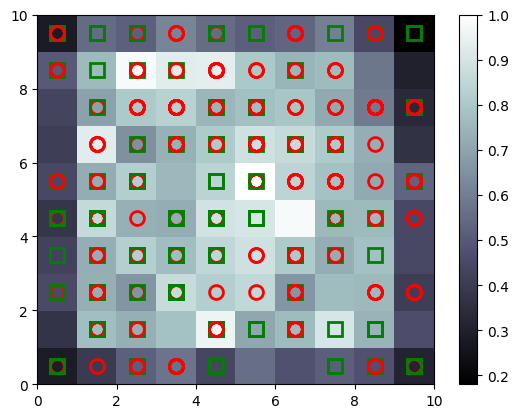

In [4]:
#Self Organizing Map 
#Importing The Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Importing The Dataset
dataset = pd.read_csv('D:/Download/Part 4 - Self Organizing Maps (SOM)/Credit_Card_Applications.csv')

#pairnoume ola ta dedomena sto x gia ekpaideush kai thn metauliti
#poy 8eloume na brei sto y
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

#Feature Scalling
from sklearn.preprocessing import MinMaxScaler
sc =MinMaxScaler(feature_range = (0,1))
x= sc.fit_transform(x)

#Training the SOM
from minisom import MiniSom

som = MiniSom(x = 10, y = 10, input_len = 15, sigma = 1.0, learning_rate = 0.5)

som.random_weights_init(x)
som.train_random(data = x, num_iteration = 100)

#Visualizing The Results
from pylab import bone, pcolor, plot, show, colorbar

bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors = ['r', 'g']

for i, X in enumerate(x):
    w = som.winner(X)
    plot(w[0] + 0.5, 
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10, 
         markeredgewidth = 2)
show()




In [6]:
#Finding the frauds

mappings = som.win_map(x)
frauds = np.concatenate((mappings[(5,1)], mappings[(6,5)]), axis = 0)
frauds = sc.inverse_transform(frauds)
print(frauds)

[[1.5723827e+07 1.0000000e+00 7.6750000e+01 2.2290000e+01 2.0000000e+00
  1.0000000e+01 9.0000000e+00 1.2750000e+01 1.0000000e+00 1.0000000e+00
  1.0000000e+00 1.0000000e+00 2.0000000e+00 0.0000000e+00 1.1000000e+02]
 [1.5725028e+07 1.0000000e+00 6.5420000e+01 1.1000000e+01 2.0000000e+00
  1.0000000e+01 9.0000000e+00 2.0000000e+01 1.0000000e+00 1.0000000e+00
  7.0000000e+00 1.0000000e+00 2.0000000e+00 2.2000000e+01 1.0000000e+00]
 [1.5731989e+07 1.0000000e+00 6.7750000e+01 5.5000000e+00 2.0000000e+00
  1.0000000e+01 9.0000000e+00 1.3000000e+01 1.0000000e+00 1.0000000e+00
  1.0000000e+00 1.0000000e+00 2.0000000e+00 0.0000000e+00 1.0000000e+00]
 [1.5623668e+07 1.0000000e+00 5.1830000e+01 3.0000000e+00 1.0000000e+00
  1.0000000e+00 1.0000000e+00 1.5000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 2.0000000e+00 1.8000000e+02 5.0000000e+00]
 [1.5686670e+07 1.0000000e+00 2.6830000e+01 5.4000000e-01 2.0000000e+00
  4.0000000e+00 1.0000000e+00 0.0000000e+00 0.0000000e+00 0.

In [9]:
#Part 2 Going from Unsupervised to Supervised learing
customers = dataset.iloc[:, 1:].values

#Creating the dependent viriable

is_fraud = np.zeros(len(dataset))

for i in range(len(dataset)):
    if dataset.iloc[i,0] in frauds:
        is_fraud[i] = 1
#print(is_fraud)


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [16]:
#Make the ANN model
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
#Feature Scalling
sc = StandardScaler()
customers = sc.fit_transform(customers)


classifier = Sequential()
#Adding an Input Layer and the first Hidden Layer
classifier.add(Dense(units = 2, kernel_initializer = 'uniform', activation= 'relu', input_dim= 15))

#Adding the Output Layer
classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation= 'sigmoid'))
#Compiling the ANN
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics= ['accuracy'])

classifier.fit(customers, is_fraud, batch_size= 1, epochs = 2)

#Predict the propabilities of fraud
y_pred = classifier.predict(customers)
y_pred = np.concatenate((dataset.iloc[:, 0:1],).values, axis = 1)
y_pred = y_pred[y_pred[:,1].argsort()]
print(y_pred)

Epoch 1/2


D:\Anacoda\lib\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


690/690 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9810 - loss: 0.5696
Epoch 2/2
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9853 - loss: 0.1652
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


AttributeError: 'tuple' object has no attribute 'values'

In [22]:
#Predict the propabilities of fraud
y_pred = classifier.predict(customers)
y_pred = np.concatenate((dataset.iloc[:, 0:1].values,y_pred), axis = 1)
y_pred = y_pred[y_pred[:,1].argsort()]
print(y_pred)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
[[1.56214230e+07 6.05609827e-03]
 [1.57997850e+07 1.09174959e-02]
 [1.57067620e+07 1.39271552e-02]
 ...
 [1.56472950e+07 1.91278055e-01]
 [1.57672640e+07 1.91727534e-01]
 [1.58137180e+07 2.66234994e-01]]
